In [ ]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt

from pyriodic import Circular, CircPlot
from pyriodic.preproc import RawSignal
from pyriodic.phase_events import create_phase_events
from pyriodic.datasets import sample
from pyriodic.permutation import permutation_test_against_surrogate

## Single-level analysis


In [38]:
path = sample.data_path() 

with open(path, "rb") as f:
    data = pkl.load(f)

behav_data = data["behav_data"]
resp_ts, sfreq, event_samples, event_ids, labels = data["resp_ts"], data["sfreq"], behav_data["event_samples"], behav_data["event_ids"], behav_data["event_type"]


In [39]:
start_sample = event_samples[0] - 1000  # start 1000 samples before the first event

# subtract start sample from events (the first column)
event_samples -= start_sample
resp_ts = resp_ts[start_sample:]

target_event_samples = [
    samp for samp, label in zip(event_samples, labels) if "target" in label
]

# initialise RawSignal object
raw = RawSignal(resp_ts, fs=sfreq)

In [40]:
raw.filter_bandpass(low=0.1, high=1.0)
raw.smoothing(window_size=500)
raw.zscore()

PA, peaks, troughs = raw.phase_twopoint(prominence=0.1)

In [41]:
circ = create_phase_events(
    PA, events=target_event_samples
)

Rejected 0 out of 416 events (0.0%)


In [42]:
surr_samples = surrogate_shuffle_breath_cyclehs(
    PA, target_event_samples, 
    n_surrogate=1000
)

100%|██████████| 1000/1000 [00:24<00:00, 41.22it/s]


Generated 1000 surrogate time series by shuffling breathing cycles.
Surrogate time series shape: (1000, 2758141)


In [43]:
# Run permutation test
obs_stat, pval = permutation_test_against_surrogate(
    circ.data,
    surrogate_samples=surr_samples,
    alternative="greater",
    n_permutations = 1000,
)

p val: 0.000999000999000999, observed stat: 779464.500, mean null stat: 499991.018


Let's visually compare the observed phase angles of the target stimuli to a null distribution of phase angles drawn from the full respiratory cycle by plotting the mean resultant vector length and the mean angle for both the observed target phase angles and a sample of null phase angles. Note that this is not the statistical test, but rather a visualisation of the data.

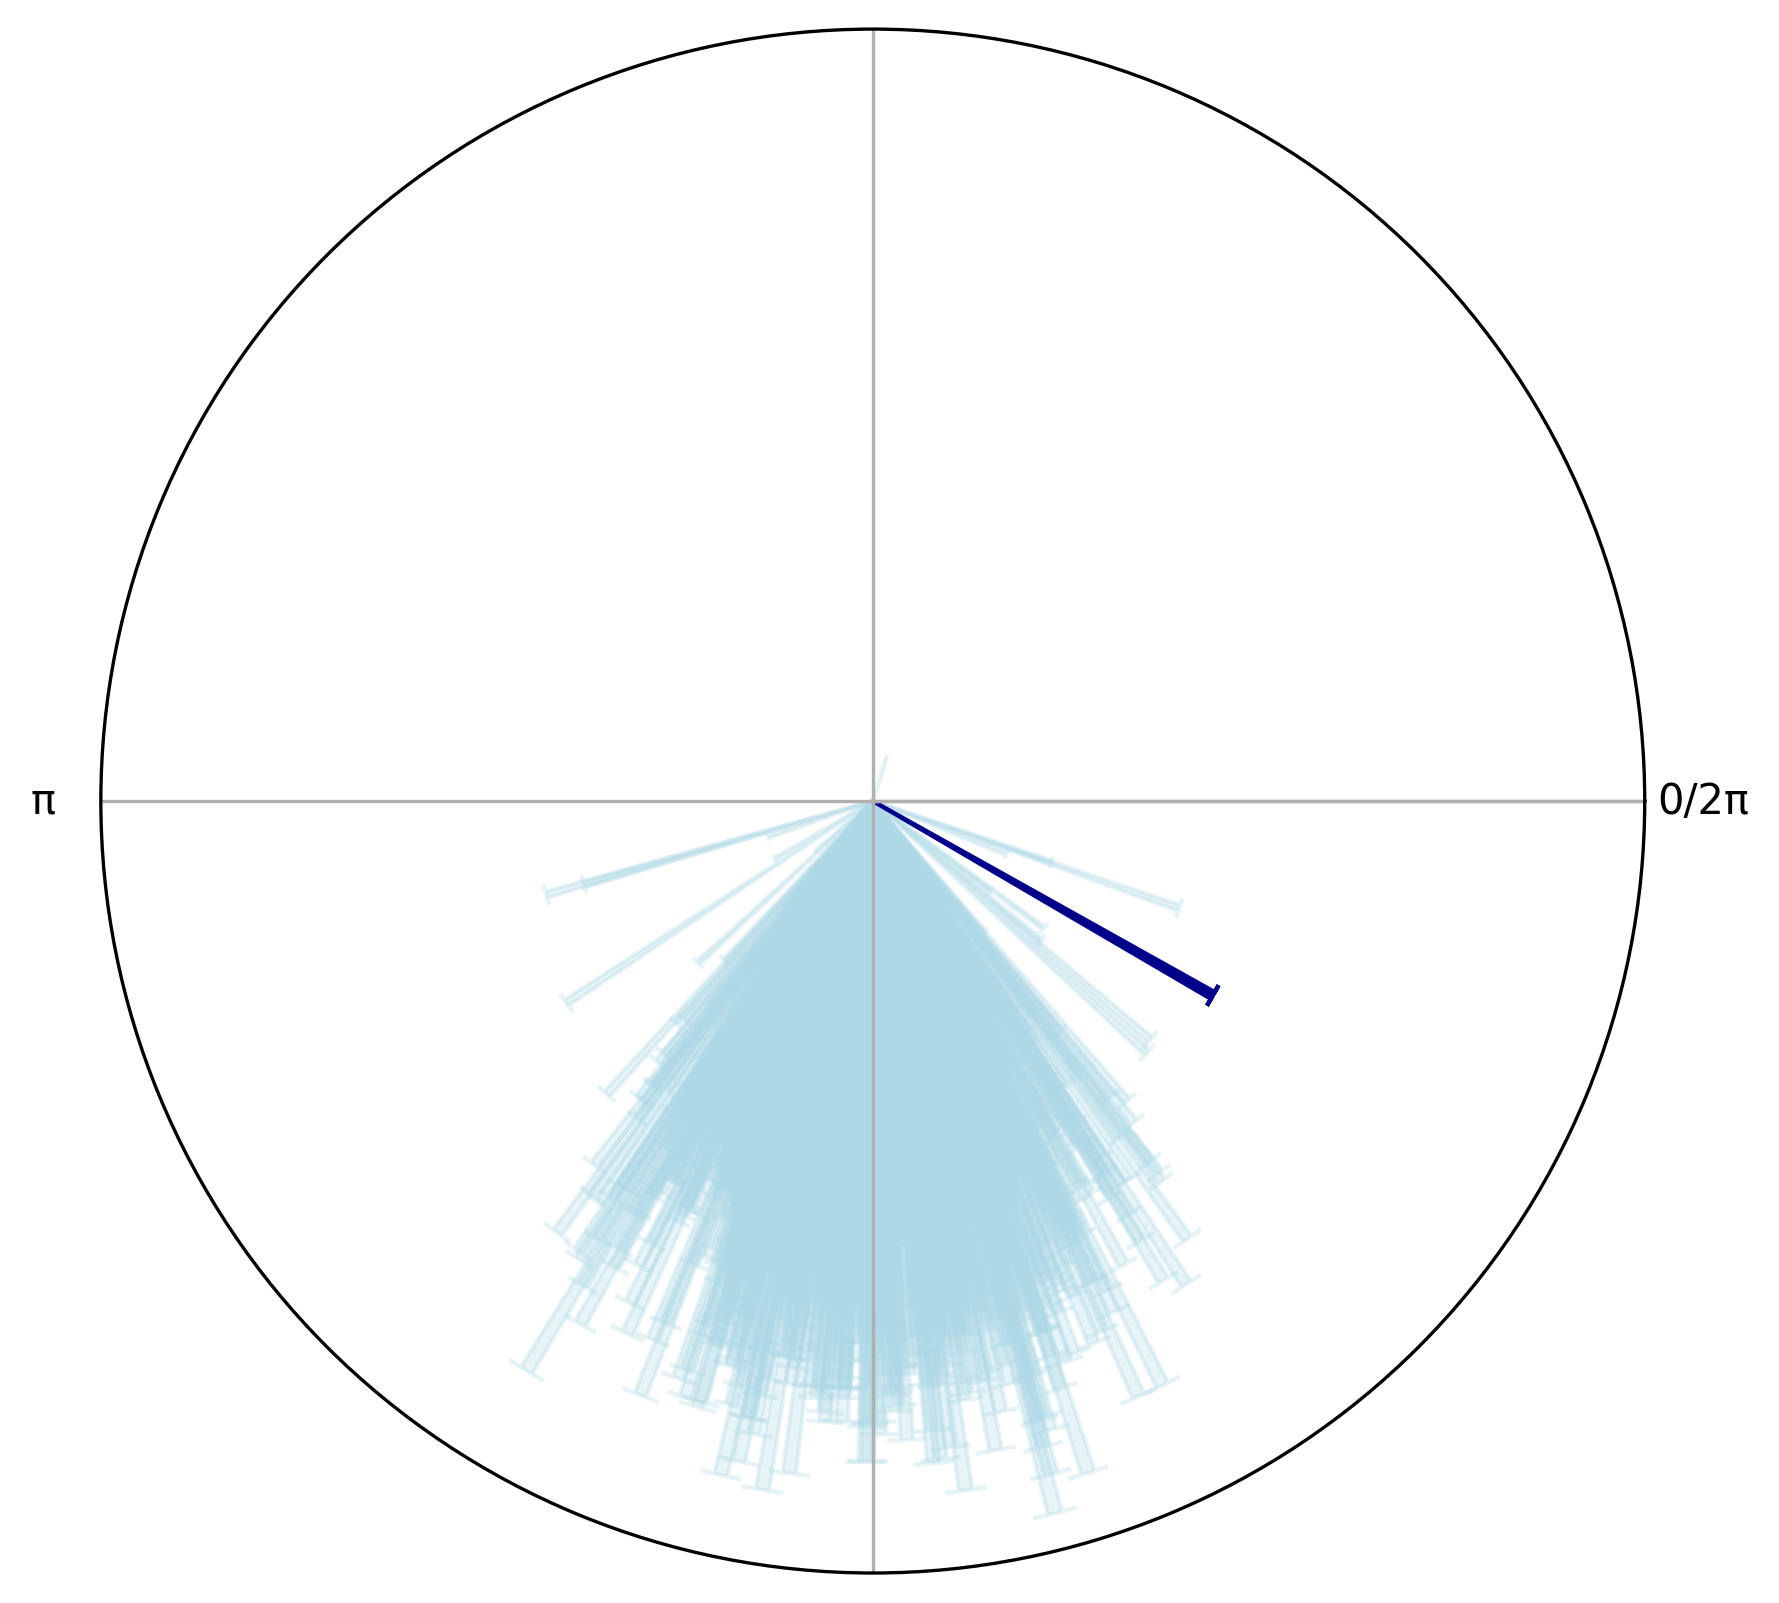

In [44]:
# make a circular object with the null_samples for plotting
circ_surr = Circular.from_multiple(
    [Circular(samp, labels=[i]*len(samp)) for i, samp in enumerate(surr_samples)]
)

circplot_surr = CircPlot(circ_surr)
circplot_surr.add_circular_mean(color = "lightblue", alpha = 0.3)
circplot_surr.add_arrows(
    np.array([circ.mean()]),
    np.array([circ.r()]),
    color="darkblue"
)

plt.tight_layout()